# 02 — Counterfactual emissions

Hold each month's *real* total generation exactly as observed and only re-slice it across
fuels under stylised national scenarios. This isolates what fuel-mix choices alone could
do; it is not a feasibility model (no capacity, storage, retirement or cost modelling).

| Scenario | Definition |
|---|---|
| `Baseline` | observed mix and emissions, 2018–2025 |
| `FrozenMix2018` | every month re-sliced by 2018's annual fuel-mix shares — "what did the transition so far actually buy?" |
| `GrowthServedClean` | each fossil fuel held at its 2018 same-calendar-month generation; all generation growth since served by zero-carbon — an upper-bound flavour |
| `CoalHalvedToGas` | 50% of each month's coal generation reassigned to gas — a near-term redispatch lever (gas plants exist) |

Emissions for the re-sliced scenarios use each fuel's *implied* CO₂ intensity (period-total
reported mtCO₂ ÷ TWh) — derived from the data, not assumed.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DB = os.path.join("..", "malaysia_power.db")
OUT = os.path.join("..", "outputs")
os.makedirs(OUT, exist_ok=True)
assert os.path.exists(DB), "run `python scripts/build_db.py` from the repo root first"

con = sqlite3.connect(DB)
gen = pd.read_sql_query(
    """SELECT m.month_id, m.year, m.month, m.month_start, f.fuel_name,
              g.twh, g.share_pct, e.mtco2
       FROM fact_generation_monthly g
       JOIN dim_month m USING(month_id)
       JOIN dim_fuel  f USING(fuel_id)
       JOIN fact_emissions_monthly e USING(month_id, fuel_id)""", con)
summ = pd.read_sql_query(
    """SELECT m.month_id, m.year, m.month, m.month_start,
              s.total_gen_twh, s.total_emissions_mtco2, s.co2_intensity_g_per_kwh,
              d.demand_twh, d.net_imports_twh
       FROM fact_summary_monthly s
       JOIN dim_month m USING(month_id)
       JOIN fact_demand_monthly d USING(month_id)""", con)
con.close()
gen["date"] = pd.to_datetime(gen["month_start"])
summ["date"] = pd.to_datetime(summ["month_start"])
FUEL_ORDER = ["Coal", "Gas", "Other Fossil", "Hydro", "Bioenergy", "Solar"]
FUEL_COLOR = {"Coal": "#3f3f46", "Gas": "#f59e0b", "Other Fossil": "#a16207",
              "Hydro": "#2563eb", "Bioenergy": "#16a34a", "Solar": "#fbbf24"}
print(f"{gen.month_id.nunique()} months {gen.year.min()}-{gen.year.max()}, {gen.fuel_name.nunique()} fuels")

96 months 2018-2025, 6 fuels


In [2]:
# implied emission intensity per fuel (tCO2/MWh), from the data
EF = gen.groupby("fuel_name").apply(lambda d: d.mtco2.sum() / d.twh.sum() if d.twh.sum() else 0.0).to_dict()
FUELS = list(gen.fuel_name.unique())
print("implied tCO2/MWh:", {k: round(v, 3) for k, v in EF.items()})

base = gen.pivot_table(index="month_id", columns="fuel_name", values="twh").reindex(columns=FUELS)
base_emis = gen.pivot_table(index="month_id", columns="fuel_name", values="mtco2").reindex(columns=FUELS)
months = base.index.tolist()
month_year = gen.drop_duplicates("month_id").set_index("month_id")["year"].to_dict()
month_cal = gen.drop_duplicates("month_id").set_index("month_id")["month"].to_dict()
total_gen = base.sum(axis=1)

FOSSIL = ["Coal", "Gas", "Other Fossil"]

# 2018 annual mix shares, and 2018 generation by (calendar-month, fuel)
g2018 = base.loc[[m for m in months if month_year[m] == 2018]]
mix2018 = (g2018.sum() / g2018.sum().sum()).to_dict()
gen2018_by_calmonth = {}  # (cal_month, fuel) -> 2018 TWh
for m in [m for m in months if month_year[m] == 2018]:
    for f in FUELS:
        gen2018_by_calmonth[(month_cal[m], f)] = base.loc[m, f]
print("2018 mix:", {k: round(v * 100, 1) for k, v in mix2018.items()})

implied tCO2/MWh: {'Bioenergy': 0.23, 'Coal': 0.896, 'Gas': 0.672, 'Hydro': 0.024, 'Other Fossil': 0.721, 'Solar': 0.036}
2018 mix: {'Coal': 43.7, 'Gas': 37.9, 'Hydro': 16.1, 'Solar': 0.0, 'Bioenergy': 1.9, 'Other Fossil': 0.3}


/var/folders/r2/4smyvh4x7kz6stwx4j708npr0000gn/T/ipykernel_60389/2316346380.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  EF = gen.groupby("fuel_name").apply(lambda d: d.mtco2.sum() / d.twh.sum() if d.twh.sum() else 0.0).to_dict()


In [3]:
def emissions_for(scenario):
    """Return a Series of monthly total emissions (Mt CO2) under the scenario."""
    out = {}
    for m in months:
        T = total_gen[m]
        if scenario == "Baseline":
            out[m] = base_emis.loc[m].sum()
        elif scenario == "FrozenMix2018":
            out[m] = sum(T * mix2018[f] * EF[f] for f in FUELS)
        elif scenario == "GrowthServedClean":
            # each fossil fuel held at its 2018 same-calendar-month level; the rest is zero-carbon
            foss = sum(gen2018_by_calmonth[(month_cal[m], f)] for f in FOSSIL)
            foss = min(foss, T)  # never exceed actual total
            out[m] = sum(gen2018_by_calmonth[(month_cal[m], f)] * EF[f] for f in FOSSIL) if foss == sum(gen2018_by_calmonth[(month_cal[m], f)] for f in FOSSIL) else 0.0
            # (if 2018 fossil already exceeds today's total, fall back to scaling — doesn't happen here, but be safe)
            tot_foss_2018 = sum(gen2018_by_calmonth[(month_cal[m], f)] for f in FOSSIL)
            if tot_foss_2018 > T:
                scale = T / tot_foss_2018
                out[m] = sum(gen2018_by_calmonth[(month_cal[m], f)] * scale * EF[f] for f in FOSSIL)
            else:
                out[m] = sum(gen2018_by_calmonth[(month_cal[m], f)] * EF[f] for f in FOSSIL)
        elif scenario == "CoalHalvedToGas":
            coal, gas = base.loc[m, "Coal"], base.loc[m, "Gas"]
            moved = 0.5 * coal
            e = base_emis.loc[m].sum() - base_emis.loc[m, "Coal"] - base_emis.loc[m, "Gas"]
            e += (coal - moved) * EF["Coal"] + (gas + moved) * EF["Gas"]
            out[m] = e
        else:
            raise ValueError(scenario)
    return pd.Series(out, name=scenario)

SCEN = ["Baseline", "FrozenMix2018", "GrowthServedClean", "CoalHalvedToGas"]
em = pd.DataFrame({sc: emissions_for(sc) for sc in SCEN})
em["year"] = [month_year[m] for m in em.index]
em["date"] = pd.to_datetime(gen.drop_duplicates("month_id").set_index("month_id")["month_start"].reindex(em.index))
annual = em.groupby("year")[SCEN].sum().round(2)
print("Annual emissions by scenario (Mt CO2):")
print(annual.to_string())

Annual emissions by scenario (Mt CO2):
      Baseline  FrozenMix2018  GrowthServedClean  CoalHalvedToGas
year                                                             
2018    106.40         105.98             104.64            98.10
2019    109.14         109.49             104.64           101.05
2020    105.38         104.79             104.64            96.45
2021    104.86         107.90             104.64            96.61
2022    108.62         112.86             104.64           100.59
2023    112.17         115.20             104.64           103.72
2024    117.20         121.98             104.64           108.33
2025    119.42         123.93             104.64           110.06


wrote outputs/counterfactual_annual.csv


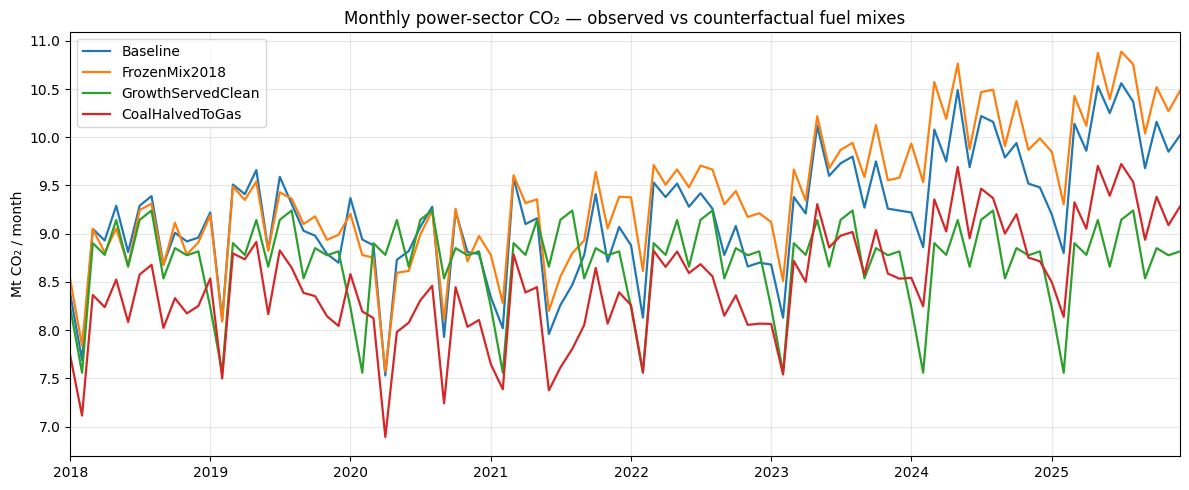

In [4]:
ann_long = annual.reset_index().melt(id_vars="year", var_name="scenario", value_name="mtco2")
ann_long.to_csv(os.path.join(OUT, "counterfactual_annual.csv"), index=False)
print("wrote outputs/counterfactual_annual.csv")

fig, ax = plt.subplots(figsize=(12, 5))
for sc in SCEN:
    ax.plot(em["date"], em[sc], lw=1.6, label=sc)
ax.set_ylabel("Mt CO₂ / month"); ax.set_title("Monthly power-sector CO₂ — observed vs counterfactual fuel mixes")
ax.legend(); ax.grid(alpha=0.3); ax.margins(x=0); fig.tight_layout()
fig.savefig(os.path.join(OUT, "counterfactual_monthly.png"), dpi=130); plt.show()

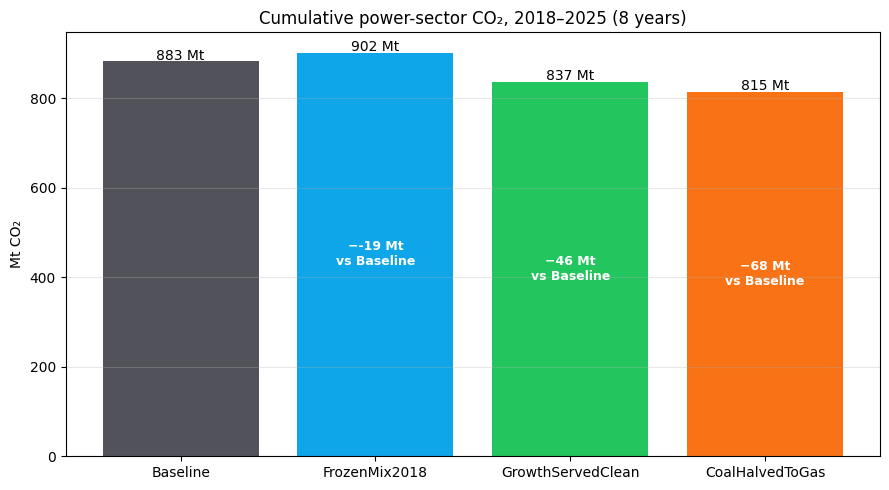

In [5]:
cum = em[SCEN].sum()
avoided = cum["Baseline"] - cum
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(SCEN, cum.values, color=["#52525b", "#0ea5e9", "#22c55e", "#f97316"])
for b, sc in zip(bars, SCEN):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 3, f"{cum[sc]:.0f} Mt", ha="center", fontsize=10)
    if sc != "Baseline":
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() / 2, f"−{avoided[sc]:.0f} Mt\nvs Baseline",
                ha="center", va="center", fontsize=9, color="white", fontweight="bold")
ax.set_ylabel("Mt CO₂"); ax.set_title("Cumulative power-sector CO₂, 2018–2025 (8 years)")
ax.grid(alpha=0.3, axis="y"); fig.tight_layout()
fig.savefig(os.path.join(OUT, "counterfactual_summary.png"), dpi=130); plt.show()

In [6]:
PRICE_TAX, PRICE_BCX = 20.0, 50.0   # RM/tonne -- projected 2026 carbon-tax low end; BCX nature-based floor (Jul 2024)
summary = pd.DataFrame({
    "cumulative_Mt_CO2": cum.round(1),
    "avoided_vs_Baseline_Mt": avoided.round(1),
    "avoided_value_RMbn_at_RM20": (avoided * 1e6 * PRICE_TAX / 1e9).round(2),
    "avoided_value_RMbn_at_RM50": (avoided * 1e6 * PRICE_BCX / 1e9).round(2),
})
print(summary.to_string())
print(f"\nFor reference, Baseline's own {cum['Baseline']:.0f} Mt over 8 years would carry a carbon cost of")
print(f"RM {cum['Baseline']*1e6*PRICE_TAX/1e9:.1f} bn at RM20/t and RM {cum['Baseline']*1e6*PRICE_BCX/1e9:.1f} bn at RM50/t.")

                   cumulative_Mt_CO2  avoided_vs_Baseline_Mt  avoided_value_RMbn_at_RM20  avoided_value_RMbn_at_RM50
Baseline                       883.2                     0.0                        0.00                        0.00
FrozenMix2018                  902.1                   -18.9                       -0.38                       -0.95
GrowthServedClean              837.2                    46.0                        0.92                        2.30
CoalHalvedToGas                814.9                    68.3                        1.37                        3.41

For reference, Baseline's own 883 Mt over 8 years would carry a carbon cost of
RM 17.7 bn at RM20/t and RM 44.2 bn at RM50/t.


## Honesty caveats

These scenarios hold total generation constant and only redistribute it across fuels. They
do **not** model capacity constraints, transmission and storage costs, plant retirement
schedules, capital costs of new build, or demand response. `GrowthServedClean` in
particular is an upper bound — "what if every extra MWh since 2018 had been zero-carbon" —
not a feasible pathway. `FrozenMix2018` is the most informative one: it isolates what the
fuel-mix change actually achieved (and the answer, on this data, is: not much). Treat the
annual and cumulative figures as the load-bearing numbers and the avoided-emissions deltas
as order-of-magnitude.

One dataset note: emissions for the re-sliced scenarios use each fuel's *implied* intensity
(period-total reported CO₂ ÷ TWh, from Ember). Ember's reported intensities include some
non-zero figures for hydro/bioenergy and a gas intensity higher than a textbook CCGT — that
is Ember's accounting, carried through as-is rather than overridden.

## Appendix — can the fuel mix be predicted, and from what?

A behavioural objection to the counterfactual: maybe the mix isn't a free choice — maybe it
tracks demand and seasonality, and the observed path is roughly mechanical. Below, the
monthly national **coal share** is regressed on demand, calendar-month dummies, and a linear
time trend — all real, no prices (there is no real Malaysia-specific monthly fuel-price
series; see the README, §7). The question: how much of the month-to-month coal share is
explained by load + season + trend, and is there much left over for "choice"?

In [7]:
import statsmodels.formula.api as smf

d = summ[["year", "month", "demand_twh"]].copy()
d["coal_share"] = gen[gen.fuel_name == "Coal"].set_index("month_id")["share_pct"].reindex(
    gen.drop_duplicates("month_id").sort_values("month_id")["month_id"].values).values
d["t"] = np.arange(len(d))           # linear trend (months since 2018-01)

m_dem  = smf.ols("coal_share ~ demand_twh", data=d).fit()
m_seas = smf.ols("coal_share ~ demand_twh + C(month)", data=d).fit()
m_full = smf.ols("coal_share ~ demand_twh + C(month) + t", data=d).fit()
print(f"n = {len(d)} months")
print(f"  coal_share ~ demand                    : R^2 = {m_dem.rsquared:.3f}")
print(f"  coal_share ~ demand + month dummies     : R^2 = {m_seas.rsquared:.3f}")
print(f"  coal_share ~ demand + month + trend     : R^2 = {m_full.rsquared:.3f}   (trend coef {m_full.params['t']:+.4f} pp/month, p = {m_full.pvalues['t']:.3f})")
resid_sd = m_full.resid.std()
print(f"\nVerdict:")
print(f"  These regressions explain very little. Demand alone gets R^2 = {m_dem.rsquared:.2f} -- the coal *share*")
print(f"  barely tracks load (coal is a near-baseload fleet; load swings get absorbed elsewhere). Adding")
print(f"  calendar-month dummies and a linear trend only reaches R^2 = {m_full.rsquared:.2f}, leaving a residual SD of")
print(f"  about {resid_sd:.1f} percentage points -- so {100*(1-m_full.rsquared):.0f}% of the month-to-month coal share is idiosyncratic: plant")
print(f"  outages, hydro availability, gas supply, dispatch quirks. And the trend term is {m_full.params['t']:+.3f} pp/month")
print(f"  with p = {m_full.pvalues['t']:.2f} -- i.e. not statistically distinguishable from flat. There is no measurable")
print(f"  downward trend in the coal share over 2018-2025, and there is no tidy macro story behind it either.")
print(f"  Two lessons: don't model a generation mix as a smooth function of observable drivers -- it's a lumpy")
print(f"  fleet, dominated at monthly frequency by outages and resource availability; and if a 'transition'")
print(f"  signal is in this series at all, it's below the noise floor.")

n = 96 months
  coal_share ~ demand                    : R^2 = 0.014
  coal_share ~ demand + month dummies     : R^2 = 0.161
  coal_share ~ demand + month + trend     : R^2 = 0.177   (trend coef +0.0265 pp/month, p = 0.213)

Verdict:
  These regressions explain very little. Demand alone gets R^2 = 0.01 -- the coal *share*
  barely tracks load (coal is a near-baseload fleet; load swings get absorbed elsewhere). Adding
  calendar-month dummies and a linear trend only reaches R^2 = 0.18, leaving a residual SD of
  about 3.0 percentage points -- so 82% of the month-to-month coal share is idiosyncratic: plant
  outages, hydro availability, gas supply, dispatch quirks. And the trend term is +0.026 pp/month
  with p = 0.21 -- i.e. not statistically distinguishable from flat. There is no measurable
  downward trend in the coal share over 2018-2025, and there is no tidy macro story behind it either.
  Two lessons: don't model a generation mix as a smooth function of observable drivers -- it's a